# Основы синтеза речи №1

##  План

1. Предобработка данных
2. Примеры применения готовых моделей
5. Оценка качества

## №0. Библиотеки

1. torch
2. torchaudio
3. librosa
4. Прочее - torchvision, torchtext, transformers
5. Утилитарные библиотеки - pandas, numpy, matplotlib, scikit-learn, tqdm, ipywidgets

### Дополнительно

1. ffmpeg - ядро обработки аудио и видео данных, используется как бекэнд в различных библиотеках

In [1]:
# !pip install torch torchaudio torchvision torchtext transformers pandas numpy tqdm matplotlib scikit-learn ipywidgets

In [1]:
import torch
import torchaudio

from tqdm.auto import tqdm

## №1. Предобработка данных

![image.png](https://download.pytorch.org/torchaudio/tutorial-assets/torchaudio_feature_extractions.png)

Будем использовать семплы из датасета [RUSLAN](https://ruslan-corpus.github.io)

Шаги:
1. Читаем аудио
2. Делаем ресемплинг
3. Преобразуем в мел-спектрограмму
4. Преобразуем назад для проверки

In [3]:
import torchaudio
import torchaudio.functional as F
import torchaudio.transforms as T
from IPython.display import display, Audio

In [4]:
wav, sr = torchaudio.load("https://ruslan-corpus.github.io/audio/01.wav")

In [5]:
display(Audio(wav, rate=sr))

In [6]:
wav.shape, sr

(torch.Size([1, 172871]), 44100)

In [8]:
new_sr = 22050
new_wav = F.resample(wav, sr, new_sr)

In [9]:
new_wav.shape

torch.Size([1, 86436])

In [10]:
display(Audio(new_wav, rate=sr))

In [11]:
display(Audio(new_wav, rate=new_sr))

In [12]:
T.MelSpectrogram?

In [13]:
1024 / 22050

0.046439909297052155

In [14]:
SAMPLE_RATE = 22050
N_FFT = 1024
WIN_LENGTH = 1024
HOP_LENGTH = 256
F_MIN = 0
F_MAX = 8000
PAD = (N_FFT - HOP_LENGTH) // 2
N_MELS = 80
POWER = 1.5

In [15]:
melspec_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    f_min=F_MIN,
    f_max=F_MAX,
    pad=((N_FFT - HOP_LENGTH) // 2),
    n_mels=N_MELS,
    power=POWER,
    mel_scale='slaney',
    center=False,
)

In [16]:
mel = melspec_transform(new_wav)

In [17]:
mel.shape

torch.Size([1, 80, 337])

In [19]:
T.InverseMelScale?

In [20]:
T.GriffinLim?

In [27]:
inversemel_transform = T.InverseMelScale(
    sample_rate=SAMPLE_RATE,
    n_stft=(N_FFT // 2) + 1,
    f_min=F_MIN,
    f_max=F_MAX,
    n_mels=N_MELS,
    mel_scale='slaney',
)
griffinlim_transform = T.GriffinLim(
    n_fft=N_FFT,
    win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH,
    power=POWER,
)

In [28]:
restored_wav = griffinlim_transform(inversemel_transform(mel))

In [29]:
display(Audio(restored_wav, rate=new_sr))

## №2. Пробуем синтезировать речь

Готовые модели из torchaudio: https://docs.pytorch.org/audio/stable/models.html

In [30]:
from torchaudio.pipelines import TACOTRON2_GRIFFINLIM_CHAR_LJSPEECH

In [31]:
processor = TACOTRON2_GRIFFINLIM_CHAR_LJSPEECH.get_text_processor()
tacotron2 = TACOTRON2_GRIFFINLIM_CHAR_LJSPEECH.get_tacotron2()
vocoder = TACOTRON2_GRIFFINLIM_CHAR_LJSPEECH.get_vocoder()

Downloading: "https://download.pytorch.org/torchaudio/models/tacotron2_english_characters_1500_epochs_ljspeech.pth" to /root/.cache/torch/hub/checkpoints/tacotron2_english_characters_1500_epochs_ljspeech.pth


100%|██████████| 107M/107M [00:02<00:00, 41.3MB/s]


In [32]:
processor?

In [41]:
tacotron2?

In [ ]:
vocoder?

### Предобработка текста

In [37]:
processor.tokens

('_',
 '-',
 '!',
 "'",
 '(',
 ')',
 ',',
 '.',
 ':',
 ';',
 '?',
 ' ',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z')

In [33]:
processor("Привет, как дела?")

(tensor([[ 6, 11, 11, 10]]), tensor([4], dtype=torch.int32))

In [38]:
processor("Hello, how are you?")

(tensor([[19, 16, 23, 23, 26,  6, 11, 19, 26, 34, 11, 12, 29, 16, 11, 36, 26, 32,
          10]]),
 tensor([19], dtype=torch.int32))

In [39]:
for token in processor("Привет, как дела?")[0][0]:
    print(processor.tokens[token], end="")

,  ?

In [40]:
for token in processor("Hello, how are you?")[0][0]:
    print(processor.tokens[token], end="")

hello, how are you?

In [45]:
processor(["Hello, how are you?", "Another test text"])

(tensor([[19, 16, 23, 23, 26,  6, 11, 19, 26, 34, 11, 12, 29, 16, 11, 36, 26, 32,
          10],
         [12, 25, 26, 31, 19, 16, 29, 11, 31, 16, 30, 31, 11, 31, 16, 35, 31,  0,
           0]]),
 tensor([19, 17], dtype=torch.int32))

### Синтезируем мел-спектрограммы

In [43]:
tacotron2.eval()
# tacotron2.train()

Tacotron2(
  (embedding): Embedding(38, 512)
  (encoder): _Encoder(
    (convolutions): ModuleList(
      (0-2): 3 x Sequential(
        (0): Conv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (lstm): LSTM(512, 256, batch_first=True, bidirectional=True)
  )
  (decoder): _Decoder(
    (prenet): _Prenet(
      (layers): ModuleList(
        (0): Linear(in_features=80, out_features=256, bias=False)
        (1): Linear(in_features=256, out_features=256, bias=False)
      )
    )
    (attention_rnn): LSTMCell(768, 1024)
    (attention_layer): _Attention(
      (query_layer): Linear(in_features=1024, out_features=128, bias=False)
      (memory_layer): Linear(in_features=512, out_features=128, bias=False)
      (v): Linear(in_features=128, out_features=1, bias=False)
      (location_layer): _LocationLayer(
        (location_conv): Conv1d(2, 32, kernel_size=(31,), stride=(1

In [44]:
tacotron2.infer?

In [46]:
next(tacotron2.parameters()).device

device(type='cpu')

In [47]:
%%time

tokens, lengths = processor("Using Tacotron2 for inference.")
mels, mel_lengths, attentions = tacotron2.infer(tokens, lengths)

CPU times: user 1.16 s, sys: 6.64 ms, total: 1.17 s
Wall time: 1.19 s


#### Ускорим

In [49]:
%%time
with torch.no_grad():
    tokens, lengths = processor("Using Tacotron2 for inference.")
    mels, mel_lengths, attentions = tacotron2.infer(tokens, lengths)

CPU times: user 1.14 s, sys: 0 ns, total: 1.14 s
Wall time: 1.14 s


In [50]:
mels.shape

torch.Size([1, 80, 175])

In [52]:
tokens.shape

torch.Size([1, 29])

In [53]:
mel_lengths

tensor([175], dtype=torch.int32)

In [55]:
attentions.shape

torch.Size([1, 175, 29])

In [56]:
import matplotlib.pyplot as plt

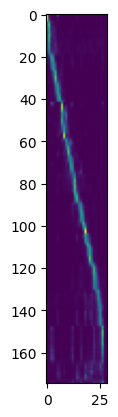

In [57]:
plt.imshow(attentions[0])

In [58]:
attentions[0]

tensor([[4.0314e-01, 7.6499e-02, 6.7648e-03,  ..., 1.1028e-03, 1.1907e-04,
         1.3892e-04],
        [7.9637e-01, 6.5789e-02, 1.5325e-02,  ..., 3.1642e-04, 1.0651e-04,
         7.4145e-06],
        [8.1242e-01, 1.3523e-01, 9.6515e-03,  ..., 2.3441e-04, 2.2583e-05,
         1.6312e-06],
        ...,
        [3.3810e-03, 2.0966e-03, 2.8841e-03,  ..., 6.2138e-02, 2.5092e-03,
         5.2140e-04],
        [6.6970e-03, 6.4626e-03, 1.0188e-02,  ..., 8.6632e-02, 6.2859e-03,
         2.4944e-03],
        [2.0573e-03, 2.2343e-03, 1.5859e-02,  ..., 2.9425e-01, 1.9377e-02,
         9.7943e-03]])

#### Пояснение

При инференсе модели не забываем torch.no_grad, чтобы не считать градиенты

In [60]:
# vocoder?

### Восстаноление аудио

In [61]:
with torch.no_grad():
    wavs, wav_lengths = vocoder(mels, mel_lengths)

In [63]:
wavs.shape

torch.Size([1, 44544])

### Послушаем

In [65]:
vocoder.sample_rate

22050

In [67]:
display(Audio(wavs.cpu().numpy()[0], rate=vocoder.sample_rate))

In [69]:
!pip install deep-phonemizer

  Preparing metadata (setup.py) ... done
  Created wheel for deep-phonemizer: filename=deep_phonemizer-0.0.19-py3-none-any.whl size=33272 sha256=37520f53a906ebe0a1fa7aa8d3e8ff57f958dca0f2b00514c47125544b32f208
  Stored in directory: /root/.cache/pip/wheels/b9/d7/45/f2ae07184a29327b2a7f93b1f734a936c3a34e57225fca603b
Successfully built deep-phonemizer


In [70]:
from torchaudio.pipelines import TACOTRON2_WAVERNN_PHONE_LJSPEECH

processor = TACOTRON2_WAVERNN_PHONE_LJSPEECH.get_text_processor()
tacotron2 = TACOTRON2_WAVERNN_PHONE_LJSPEECH.get_tacotron2().to("cuda")
vocoder = TACOTRON2_WAVERNN_PHONE_LJSPEECH.get_vocoder().to("cuda")

100%|██████████| 63.6M/63.6M [00:03<00:00, 18.2MB/s]
/usr/local/lib/python3.12/dist-packages/dp/model/model.py:69: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(encoder_layer=encoder_layer,


Downloading: "https://download.pytorch.org/torchaudio/models/tacotron2_english_phonemes_1500_epochs_wavernn_ljspeech.pth" to /root/.cache/torch/hub/checkpoints/tacotron2_english_phonemes_1500_epochs_wavernn_ljspeech.pth


100%|██████████| 107M/107M [00:00<00:00, 254MB/s] 


Downloading: "https://download.pytorch.org/torchaudio/models/wavernn_10k_epochs_8bits_ljspeech.pth" to /root/.cache/torch/hub/checkpoints/wavernn_10k_epochs_8bits_ljspeech.pth


100%|██████████| 16.7M/16.7M [00:00<00:00, 162MB/s]


In [71]:
processor.tokens

('_',
 '-',
 '!',
 "'",
 '(',
 ')',
 ',',
 '.',
 ':',
 ';',
 '?',
 ' ',
 'AA',
 'AA0',
 'AA1',
 'AA2',
 'AE',
 'AE0',
 'AE1',
 'AE2',
 'AH',
 'AH0',
 'AH1',
 'AH2',
 'AO',
 'AO0',
 'AO1',
 'AO2',
 'AW',
 'AW0',
 'AW1',
 'AW2',
 'AY',
 'AY0',
 'AY1',
 'AY2',
 'B',
 'CH',
 'D',
 'DH',
 'EH',
 'EH0',
 'EH1',
 'EH2',
 'ER',
 'ER0',
 'ER1',
 'ER2',
 'EY',
 'EY0',
 'EY1',
 'EY2',
 'F',
 'G',
 'HH',
 'IH',
 'IH0',
 'IH1',
 'IH2',
 'IY',
 'IY0',
 'IY1',
 'IY2',
 'JH',
 'K',
 'L',
 'M',
 'N',
 'NG',
 'OW',
 'OW0',
 'OW1',
 'OW2',
 'OY',
 'OY0',
 'OY1',
 'OY2',
 'P',
 'R',
 'S',
 'SH',
 'T',
 'TH',
 'UH',
 'UH0',
 'UH1',
 'UH2',
 'UW',
 'UW0',
 'UW1',
 'UW2',
 'V',
 'W',
 'Y',
 'Z',
 'ZH')

In [72]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [74]:
DEVICE

'cuda'

In [73]:
with torch.no_grad():
    tokens, lengths = processor("Using Tacotron2 for inference.")
    mels, mel_lengths, attentions = tacotron2.infer(tokens.to("cuda"), lengths.to("cuda"))

In [76]:
with torch.no_grad():
    wavs, wav_lengths = vocoder(mels, mel_lengths)
wavs.shape

torch.Size([1, 47300])

In [79]:
vocoder.sample_rate

22050

In [80]:
display(Audio(wavs.cpu().numpy()[0], rate=vocoder.sample_rate))

## №3. Оценка качества

https://docs.pytorch.org/audio/master/tutorials/squim_tutorial.html

In [81]:
from torchaudio.pipelines import SQUIM_OBJECTIVE, SQUIM_SUBJECTIVE

In [93]:
objective = SQUIM_OBJECTIVE.get_model().to("cuda")
subjective = SQUIM_SUBJECTIVE.get_model().to("cuda")

In [99]:
wavs = F.resample(wavs, vocoder.sample_rate, 16000)

In [100]:
with torch.no_grad():
    stoi, pesq, si_sdr = objective(wavs)

In [101]:
stoi, pesq, si_sdr

(tensor([0.9876], device='cuda:0'),
 tensor([3.5196], device='cuda:0'),
 tensor([23.2395], device='cuda:0'))

In [102]:
ref, sr = torchaudio.load("https://ruslan-corpus.github.io/audio/01.wav")
ref = F.resample(ref, sr, 16000)

In [103]:
with torch.no_grad():
    mos = subjective(wavs, ref.to("cuda"))

In [104]:
mos

tensor([4.0237], device='cuda:0')